# Code for Calculating the Frobenius Norm of target unitary from different GRAPE functions

In this notebook, we use two different functions from the qutip control library ("optimize_pulse_unitary" from the pulseoptim object and "cy_grape_unitary" from the grape object), in order to implement the GRAPE algorithm. From this we obtain a final Unitary $\hat U$ which should be close to some given target Unitary $\hat U^*$. We then calculate the Frobenius norm squared of the difference between these two unitary as a measure of the error fidelity:

$$ || A  ||_{F}^2  = Tr(A^{\dagger}A) = \sum_{ij}^{N} |A_{ij}|^{2}$$


These values are then plotted against previously obtained results which obtained the unitary by reformulating the system in terms of a polynomial equation (https://arxiv.org/pdf/2209.05790.pdf) 

## Imports

Below are the necessary imports for running this code:

1) Qutip functions: 


The first line does import all qutip functions from the base object, which is used here to convery numpy arrays to Quantum objects using Qobj() and qeye() to create an identity operator of a specified size (here 3) as the initial starting point for the GRAPE algorithm.

The next set of imports are functions used for the pulseoptim class and a logger class which formats the result when being printed to terminal/ saving the to a file (I don't think we need them)

The final set of qutip imports are for implementing the cy_grape method. The TextProgressBar is justed used as a convenient way of tracking the progress of the function. (plot_grape_control_fields and _overlap are not necessary any more but are just used as tools for plotting the grape control fields and calculating the trace norm respectively)

2) Other imports:


The next set of imports are just the basic imports for simple tasks: 
matplotlib for plotting. 

numpy for storing and manipulating data.

h5py for reading and writing hdf5 files. 

time for time-keeping.  


In [33]:
from qutip import *

#QuTiP control modules
import qutip.control.pulseoptim as cpo
#import qutip.logging_utils as logging
#logger = logging.get_logger()
#Set this to None or logging.WARN for 'quiet' execution
#log_level = logging.INFO

from qutip.control import * 
from qutip.ui.progressbar import TextProgressBar
from qutip.control.grape import plot_grape_control_fields, _overlap


%matplotlib inline
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt
#import datetime
import h5py
import time 
start_time = time.time()

from tqdm.notebook import tqdm

from multiprocessing import Pool
from scipy.linalg import expm

## Preparing the input data
 
 

 
In the cell below we define a selectable catalog of fixed 3x3 target unitaries matching the POP notebook. When a matching `results.hdf5` is available, the POP target matrices and values are also loaded for comparison. 

*Note: Bottom half of this cell may change as appending to an array can be computationally expensive* 

Sample here is the number of fixed gates. Empty lists are also initialised for storing the CRAB and GRAPE outputs. 


In [34]:
# Define the same fixed three-level target catalog used by the POP notebook.

def rotation_gate(i, j, theta):
    U = np.eye(3, dtype=complex)
    c = np.cos(theta)
    s = np.sin(theta)
    U[i, i] = c
    U[j, j] = c
    U[i, j] = -s
    U[j, i] = s
    return U

def fourier_gate(d):
    omega = np.exp(2j * np.pi / d)
    return np.array([
        [omega ** (row * col) / np.sqrt(d) for col in range(d)]
        for row in range(d)
    ], dtype=complex)

def phase_rotation_gate(i, j, theta, phi):
    U = np.eye(3, dtype=complex)
    c = np.cos(theta)
    s = np.sin(theta)
    U[i, i] = c
    U[j, j] = c
    U[i, j] = -np.exp(-1j * phi) * s
    U[j, i] = np.exp(1j * phi) * s
    return U

def permutation_gate(order):
    U = np.zeros((3, 3), dtype=complex)
    for col, row in enumerate(order):
        U[row, col] = 1
    return U

TARGET_H0 = np.array(
    [[0, 0, 0],
     [0, 0.515916, 0],
     [0, 0, 1]],
    dtype=float
)
TARGET_H0 /= LA.norm(TARGET_H0, ord=np.inf)

TARGET_V = np.array(
    [[0, 0.707107, 0],
     [0.707107, 0, 1],
     [0, 1, 0]],
    dtype=float
)
TARGET_V /= LA.norm(TARGET_V, ord=np.inf)
TARGET_T = 0.5

def fourier_control(t, coeffs):
    return coeffs[0] + coeffs[1] * np.cos(2 * np.pi * t / TARGET_T) + coeffs[2] * np.sin(2 * np.pi * t / TARGET_T)

def control_unitary(coeffs, steps=400):
    dt = TARGET_T / steps
    U = np.eye(3, dtype=complex)
    for k in range(steps):
        t_mid = (k + 0.5) * dt
        H = TARGET_H0 + TARGET_V * fourier_control(t_mid, coeffs)
        U = expm(-1j * H * dt) @ U
    return U

nan_control = np.full(3, np.nan)
target_catalog_names = []
target_catalog_controls = []
target_catalog_unitaries = []

def add_target(name, U, planted_x=None):
    if planted_x is None:
        planted_x = nan_control
    target_catalog_names.append(name)
    target_catalog_controls.append(np.array(planted_x, dtype=float))
    target_catalog_unitaries.append(np.array(U, dtype=complex))

# Structured gates, from gentle local rotations to harder global transforms.
add_target("identity", np.eye(3, dtype=complex))
add_target("rotation_01_pi8", rotation_gate(0, 1, np.pi / 8))
add_target("rotation_01_pi4", rotation_gate(0, 1, np.pi / 4))
add_target("rotation_01_pi2", rotation_gate(0, 1, np.pi / 2))
add_target("rotation_12_pi8", rotation_gate(1, 2, np.pi / 8))
add_target("rotation_12_pi4", rotation_gate(1, 2, np.pi / 4))
add_target("rotation_12_pi2", rotation_gate(1, 2, np.pi / 2))
add_target("rotation_02_pi4", rotation_gate(0, 2, np.pi / 4))
add_target("phase_rotation_01_pi4", phase_rotation_gate(0, 1, np.pi / 4, np.pi / 2))
add_target("phase_rotation_12_pi4", phase_rotation_gate(1, 2, np.pi / 4, np.pi / 2))
add_target("diagonal_phase_small", np.diag([1, np.exp(1j * np.pi / 8), np.exp(-1j * np.pi / 8)]))
add_target("diagonal_phase_medium", np.diag([1, np.exp(1j * np.pi / 3), np.exp(-1j * np.pi / 5)]))
add_target("diagonal_phase_large", np.diag([1, np.exp(1j * np.pi / 2), np.exp(1j * np.pi)]))
add_target("swap_01", permutation_gate([1, 0, 2]))
add_target("swap_12", permutation_gate([0, 2, 1]))
add_target("cycle_012", permutation_gate([1, 2, 0]))
add_target("cycle_021", permutation_gate([2, 0, 1]))
add_target("fourier_dft", fourier_gate(3))
add_target("fourier_dft_dagger", fourier_gate(3).conj().T)

# Hamiltonian-native or near-native gates that should be easier or reveal reachability structure.
add_target("drift_short", expm(-1j * TARGET_H0 * (TARGET_T / 2)))
add_target("drift_free", control_unitary([0.0, 0.0, 0.0]), planted_x=[0.0, 0.0, 0.0])
add_target("drift_long", expm(-1j * TARGET_H0 * (2 * TARGET_T)))
add_target("control_only_small", expm(-1j * (0.25 * TARGET_V) * TARGET_T))
add_target("control_only_large", expm(-1j * (0.75 * TARGET_V) * TARGET_T))
add_target("const_drive_p20", control_unitary([0.20, 0.0, 0.0]), planted_x=[0.20, 0.0, 0.0])
add_target("const_drive_p50", control_unitary([0.50, 0.0, 0.0]), planted_x=[0.50, 0.0, 0.0])
add_target("const_drive_m50", control_unitary([-0.50, 0.0, 0.0]), planted_x=[-0.50, 0.0, 0.0])
add_target("cos_drive_p35", control_unitary([0.0, 0.35, 0.0]), planted_x=[0.0, 0.35, 0.0])
add_target("sin_drive_p35", control_unitary([0.0, 0.0, 0.35]), planted_x=[0.0, 0.0, 0.35])
add_target("mixed_fourier_soft", control_unitary([0.15, -0.30, 0.20]), planted_x=[0.15, -0.30, 0.20])
add_target("mixed_fourier_medium", control_unitary([0.35, 0.25, -0.30]), planted_x=[0.35, 0.25, -0.30])
add_target("mixed_fourier_strong", control_unitary([0.60, -0.40, 0.35]), planted_x=[0.60, -0.40, 0.35])
add_target("oscillatory_balanced", control_unitary([0.0, 0.65, -0.65]), planted_x=[0.0, 0.65, -0.65])

# Edit this list to choose which catalog targets to run.
selected_target_names = list(target_catalog_names)
load_pop_selection_if_available = True
selected_target_indices = [target_catalog_names.index(name) for name in selected_target_names]

target_names = list(selected_target_names)
U_targets = np.stack([target_catalog_unitaries[i] for i in selected_target_indices], axis=0)
target_planted_x = np.stack([target_catalog_controls[i] for i in selected_target_indices], axis=1)

sample = len(target_names)

# POP metrics are loaded when results.hdf5 has been regenerated by NoChebyshev.ipynb.
pop_norm_U_target_minus_obtained = np.full(sample, np.nan)
pop_fidelity = np.full(sample, np.nan)
pop_fid_error = np.full(sample, np.nan)
pop_obj_min = np.full(sample, np.nan)
pop_runtime = np.full(sample, np.nan)
pop_average_runtime = np.nan

try:
    with h5py.File("results.hdf5", "r") as resultsFile:
        stored_names = None
        stored_catalog_names = None
        if "target_names" in resultsFile:
            raw_names = resultsFile["target_names"][()]
            if isinstance(raw_names, bytes):
                stored_names = raw_names.decode().splitlines()
            elif isinstance(raw_names, str):
                stored_names = raw_names.splitlines()
            else:
                stored_names = [_.decode() if isinstance(_, bytes) else str(_) for _ in raw_names]

        if "target_catalog_names" in resultsFile:
            raw_catalog_names = resultsFile["target_catalog_names"][()]
            if isinstance(raw_catalog_names, bytes):
                stored_catalog_names = raw_catalog_names.decode().splitlines()
            elif isinstance(raw_catalog_names, str):
                stored_catalog_names = raw_catalog_names.splitlines()

        catalog_matches = stored_catalog_names == target_catalog_names
        should_load_pop_selection = load_pop_selection_if_available and catalog_matches

        if stored_names is not None and (stored_names == target_names or should_load_pop_selection):
            target_names = stored_names
        
            U_targets = resultsFile["U_targets"][...].transpose(2, 1, 0)
            sample = len(target_names)
            pop_runtime = np.full(sample, np.nan)
            pop_average_runtime = np.nan
            if "target_planted_x" in resultsFile:
                target_planted_x = resultsFile["target_planted_x"][...]
            else:
                target_planted_x = np.full((3, sample), np.nan)
            pop_norm_U_target_minus_obtained = resultsFile["norm_U_target_minus_obtained"][...]
            pop_fidelity = resultsFile["f_PSU"][...]
            pop_fid_error = 1 - pop_fidelity
            pop_obj_min = resultsFile["tssos_glob_obj_min"][...]
            if "pop_runtime" in resultsFile:
                pop_runtime = resultsFile["pop_runtime"][...]
            if "pop_average_runtime" in resultsFile:
                pop_average_runtime = float(resultsFile["pop_average_runtime"][()])
except FileNotFoundError:
    pass

# For storing the obtained unitaries and optimizer result objects.
U_final_pulseoptim = []
U_final_cyGRAPE = []
crab_results = []
grape_results = []

## Choosing input parameters

The dynamics of the system are generated by the time dependent Hamiltionian:

$$H(t) = H_{0} + \sum_{i} u_i(t)H_{i} $$

Where $H_{0}$ is the drift Hamiltonian, $H_{i}$ are the control Hamiltonians and $u_{i}$ are the control fields. 

In the cell below we create Qobjs for $H_{0}$ and the single control $H_{c}$ according to the previously mentioned paper. We choose the Identity operator as the starting point for the GRAPE algorithm. We also can set the period over which the algorithm runs and the number of time slots at which act as the number of steps taken find a minimum in the landscape. 

(See https://qutip.org/docs/latest/guide/guide-control.html and the paper above for a more detail discussion).

In [35]:
H_drift_matrix = np.array(
    [[0, 0, 0],
     [0, 3.21505101e+10, 0],
     [0, 0, 6.23173079e+10]]
)
H_drift_matrix /= H_drift_matrix.max()

H_control_matrix = np.array(
    [[0, 1, 0],
     [1, 0, 1.41421356],
     [0, 1.41421356, 0]]
)
H_control_matrix /= H_control_matrix.max()

H_drift = Qobj(H_drift_matrix)
H_control = [Qobj(H_control_matrix)] 
 
# Unitary starting point
U_0 = qeye(3)


# Number of time slots
n_ts = 8

# Time allowed for the evolution
evo_time = 0.5

print(H_control_matrix)

[[0.         0.70710678 0.        ]
 [0.70710678 0.         1.        ]
 [0.         1.         0.        ]]


## pulseoptim

In the two cells below we run the function from the pulseoptim subclass. The first cell we select some more parameters for this function, these are:
 1) fid_error_tar - when this fidelity error is achieved we can terminate the algorithm as we have sufficiently achieved our goal.
 2) max_iterations - the max number of grape iterations 
 3) max_wall_time - maximum time the algorithm runs before terminating if the target unitary has not been reached
 4) min_grad - minimum gradient to determine whether we are trapped in a local minima rather than a global minima 
 5) p_type - the type of pulse for the control fields (here set to random)
 
 
 The second cell then runs the algorithm with these parameters for each unitary in the sample size. The finial unitary is stored in the "U_final_pulseoptim" list and for each iteration the termination reason and the fidelity error is printed out. You can also extract other useful information from the result variable such as the final control fields, the number of iterations used etc. 


In [36]:
#pulse optim extra params 

# Fidelity error target
fid_err_targ = 1e-10
# Maximum iterations for the optisation algorithm
max_iter = 1000
# Maximum (elapsed) time allowed in seconds.
# Use the average POP runtime as the equal per-target CRAB/GRAPE time budget.
fallback_max_wall_time = 1000
budget_scale = 1.0
max_wall_time = budget_scale * pop_average_runtime if np.isfinite(pop_average_runtime) else fallback_max_wall_time
print(f"CRAB/GRAPE max_wall_time budget per target: {max_wall_time:.3f} s")
# Minimum gradient (sum of gradients squared)
# as this tends to 0 -> local minima has been found
min_grad = 1e-10

# pulse type alternatives: RND|ZERO|LIN|SINE|SQUARE|SAW|TRIANGLE|
p_type = 'RND' 

CRAB/GRAPE max_wall_time budget per target: 0.096 s


In [37]:
def optimize(U_tag, alg):
    return cpo.optimize_pulse_unitary(
        H_drift, H_control, U_0, Qobj(U_tag), n_ts, evo_time,
        fid_err_targ=fid_err_targ, min_grad=min_grad,
        max_iter=max_iter, max_wall_time=max_wall_time,
        # log_level=log_level,
        init_pulse_type=p_type,
        alg=alg,
        # gen_stats=True
    )

def optimize_timed(U_tag, alg):
    start = time.time()
    result = optimize(U_tag, alg)
    return result, time.time() - start

In [38]:
crab_runs = [
    optimize_timed(U_targets[i, :, :], alg='CRAB') for i in tqdm(range(sample))
]
crab_results = [run[0] for run in crab_runs]
crab_elapsed_time = np.array([run[1] for run in crab_runs], dtype=float)
U_final_pulseoptim = [result.evo_full_final for result in crab_results]
crab_optimizer_fid_error = np.array([result.fid_err for result in crab_results], dtype=float)
crab_termination_reason = [result.termination_reason for result in crab_results]

  0%|          | 0/33 [00:00<?, ?it/s]

In [39]:
grape_runs = [
    optimize_timed(U_targets[i, :, :], alg='GRAPE') for i in tqdm(range(sample))
]
grape_results = [run[0] for run in grape_runs]
grape_elapsed_time = np.array([run[1] for run in grape_runs], dtype=float)
U_final_cyGRAPE = [result.evo_full_final for result in grape_results]
grape_optimizer_fid_error = np.array([result.fid_err for result in grape_results], dtype=float)
grape_termination_reason = [result.termination_reason for result in grape_results]

  0%|          | 0/33 [00:00<?, ?it/s]


for i in tqdm(range(sample)):
    result = cpo.optimize_pulse_unitary(
                H_drift, H_control, U_0, Qobj(U_targets[i, :, :]), n_ts, evo_time, 
                fid_err_targ=fid_err_targ, min_grad=min_grad, 
                max_iter=max_iter, max_wall_time=max_wall_time, 
                # log_level=log_level,
                init_pulse_type=p_type, 
                #alg='GRAPE',
                alg='CRAB',
                gen_stats=False
            )
    print("Final fidelity error {}".format(result.fid_err))
    print("Terminated due to {}".format(result.termination_reason))
   
    #Here all terminate due to convergence however if it terminates due to a different reason may cause a problem
    #U_final_pulseoptim.append(result.evo_full_final)
    
    break

## cy_grape 

In these two cells below we set the the parameters and run the cy_grape_unitary function. There are less inputs in this method:

1) times - an array of where the number of elements = number of time slots and the final element is the period.
2) n_iterations - number of grape iterations

the second cell follows the same procedure as the cell above, however in this case we can track the progress of each iteration with TextProgressBar(). Here we only the store the final unitary, however one could extract other information from the result variable such as the final control fields (for each grape iteration). 


## Plotting Fidelity error (trace norm)
This code is for calculating the trace norm (overlap) of the obtained and target unitaries:

$\frac{1}{d} |Tr[\hat U^{\dagger}\hat U^{*}]| $,

$d$ is the dimension of $\hat U$.

(currently not plotting this just calculating it. The cells for plotting have been commented out and folded as they still use TSSOS but will modify if needed)




In [40]:
#calculating fidelity

pulseoptim_fidelity = np.zeros(sample)
cy_grape_fidelity = np.zeros(sample)


for i in range(sample):
    pulseoptim_fidelity[i] = abs(_overlap(Qobj(U_targets[i, :, :]), U_final_pulseoptim[i]))**2 
    cy_grape_fidelity[i] = abs(_overlap(Qobj(U_targets[i, :, :]), U_final_cyGRAPE[i]))**2 
    


pulseoptim_fid_error = 1 - pulseoptim_fidelity 
cy_grape_fid_error = 1 - cy_grape_fidelity

print("gate, POP_infidelity, CRAB_infidelity, GRAPE_infidelity, POP_process_fidelity, CRAB_process_fidelity, GRAPE_process_fidelity")
for i, name in enumerate(target_names):
    print(
        f"{name}, "
        f"{pop_fid_error[i]:.6e}, {pulseoptim_fid_error[i]:.6e}, {cy_grape_fid_error[i]:.6e}, "
        f"{pop_fidelity[i]:.6e}, {pulseoptim_fidelity[i]:.6e}, {cy_grape_fidelity[i]:.6e}"
    )

print("\noptimizer details")
print(f"Average POP runtime budget per target: {pop_average_runtime:.6e} s")
for i, name in enumerate(target_names):
    print(
        f"{name}: "
        f"POP_obj={pop_obj_min[i]:.6e}, POP_norm={pop_norm_U_target_minus_obtained[i]:.6e}, POP_time={pop_runtime[i]:.3f}s, "
        f"CRAB_optimizer_fid_err={crab_optimizer_fid_error[i]:.6e} ({crab_termination_reason[i]}), CRAB_time={crab_elapsed_time[i]:.3f}s, "
        f"GRAPE_optimizer_fid_err={grape_optimizer_fid_error[i]:.6e} ({grape_termination_reason[i]}), GRAPE_time={grape_elapsed_time[i]:.3f}s"
    )


gate, POP_infidelity, CRAB_infidelity, GRAPE_infidelity, POP_process_fidelity, CRAB_process_fidelity, GRAPE_process_fidelity
identity, 8.654667e-03, 4.091122e-02, 3.687410e-03, 9.913453e-01, 9.590888e-01, 9.963126e-01
rotation_01_pi8, 6.350238e-02, 5.691716e-02, 4.241434e-02, 9.364976e-01, 9.430828e-01, 9.575857e-01
rotation_01_pi4, 2.716980e-01, 2.876321e-01, 2.333347e-01, 7.283020e-01, 7.123679e-01, 7.666653e-01
rotation_01_pi2, 8.401472e-01, 8.725922e-01, 7.981910e-01, 1.598528e-01, 1.274078e-01, 2.018090e-01
rotation_12_pi8, 7.615043e-02, 8.848656e-02, 6.710748e-02, 9.238496e-01, 9.115134e-01, 9.328925e-01
rotation_12_pi4, 3.031397e-01, 2.835814e-01, 2.721987e-01, 6.968603e-01, 7.164186e-01, 7.278013e-01
rotation_12_pi2, 8.608755e-01, 8.386171e-01, 8.250795e-01, 1.391245e-01, 1.613829e-01, 1.749205e-01
rotation_02_pi4, 3.575637e-01, 3.757790e-01, 3.493895e-01, 6.424363e-01, 6.242210e-01, 6.506105e-01
phase_rotation_01_pi4, 2.453464e-01, 2.723136e-01, 2.410336e-01, 7.546536e-01, 7.2

# Writing data to hdf5

In [41]:
with h5py.File('RND_qutip_opt_results_timeslices_' +str(n_ts) + '.hdf5', 'w') as hf:
    hf.create_dataset("target_names", data="\n".join(target_names))
    hf.create_dataset("target_catalog_names", data="\n".join(target_catalog_names))
    hf.create_dataset("U_targets", data=U_targets)
    hf.create_dataset("target_planted_x", data=target_planted_x)
    hf.create_dataset("pop_fid_error", data=pop_fid_error)
    hf.create_dataset("pop_fidelity", data=pop_fidelity)
    hf.create_dataset("pop_obj_min", data=pop_obj_min)
    hf.create_dataset("pop_norm_U_target_minus_obtained", data=pop_norm_U_target_minus_obtained)
    hf.create_dataset("pop_runtime", data=pop_runtime)
    hf.create_dataset("pop_average_runtime", data=pop_average_runtime)
    hf.create_dataset("qutip_budget_wall_time", data=max_wall_time)
    hf.create_dataset("budget_scale", data=budget_scale)
    hf.create_dataset("pulseoptim_fid_error",  data=pulseoptim_fid_error)
    hf.create_dataset("cy_grape_fid_error",  data=cy_grape_fid_error)
    hf.create_dataset("pulseoptim_fidelity", data=pulseoptim_fidelity)
    hf.create_dataset("cy_grape_fidelity", data=cy_grape_fidelity)
    hf.create_dataset("crab_optimizer_fid_error", data=crab_optimizer_fid_error)
    hf.create_dataset("grape_optimizer_fid_error", data=grape_optimizer_fid_error)
    hf.create_dataset("crab_elapsed_time", data=crab_elapsed_time)
    hf.create_dataset("grape_elapsed_time", data=grape_elapsed_time)
    hf.create_dataset("crab_termination_reason", data="\n".join(crab_termination_reason))
    hf.create_dataset("grape_termination_reason", data="\n".join(grape_termination_reason))

,Gate,POP Fid. Error,CRAB Fid. Error,GRAPE Fid. Error,POP Overlap,CRAB Overlap,GRAPE Overlap,CRAB Term.,GRAPE Term.
0,identity,8.65e-03,4.09e-02,3.69e-03,0.991345,0.959089,0.996313,Max wall time exceeded,function converged
1,rotation_01_pi8,6.35e-02,5.69e-02,4.24e-02,0.936498,0.943083,0.957586,Max wall time exceeded,function converged
2,rotation_01_pi4,2.72e-01,2.88e-01,2.33e-01,0.728302,0.712368,0.766665,Max wall time exceeded,function converged
3,rotation_01_pi2,8.40e-01,8.73e-01,7.98e-01,0.159853,0.127408,0.201809,Max wall time exceeded,function converged
4,rotation_12_pi8,7.62e-02,8.85e-02,6.71e-02,0.923850,0.911513,0.932893,Max wall time exceeded,function converged
5,rotation_12_pi4,3.03e-01,2.84e-01,2.72e-01,0.696860,0.716419,0.727801,Max wall time exceeded,function converged
6,rotation_12_pi2,8.61e-01,8.39e-01,8.25e-01,0.139125,0.161383,0.174920,Max wall time exceeded,function converged
7,rotation_02_pi4,3.58e-01,3.76e-01,3.49e-01,0.642436,0.624221,0.650611,Max wall time exceeded,function converged
8,phase_rotation_01_pi4,2.45e-01,2.72e-01,2.41e-01,0.754654,0.727686,0.758966,Max wall time exceeded,function converged
9,phase_rotation_12_pi4,1.37e-01,1.61e-01,1.26e-01,0.862985,0.838851,0.873719,Max wall time exceeded,Max wall time exceeded


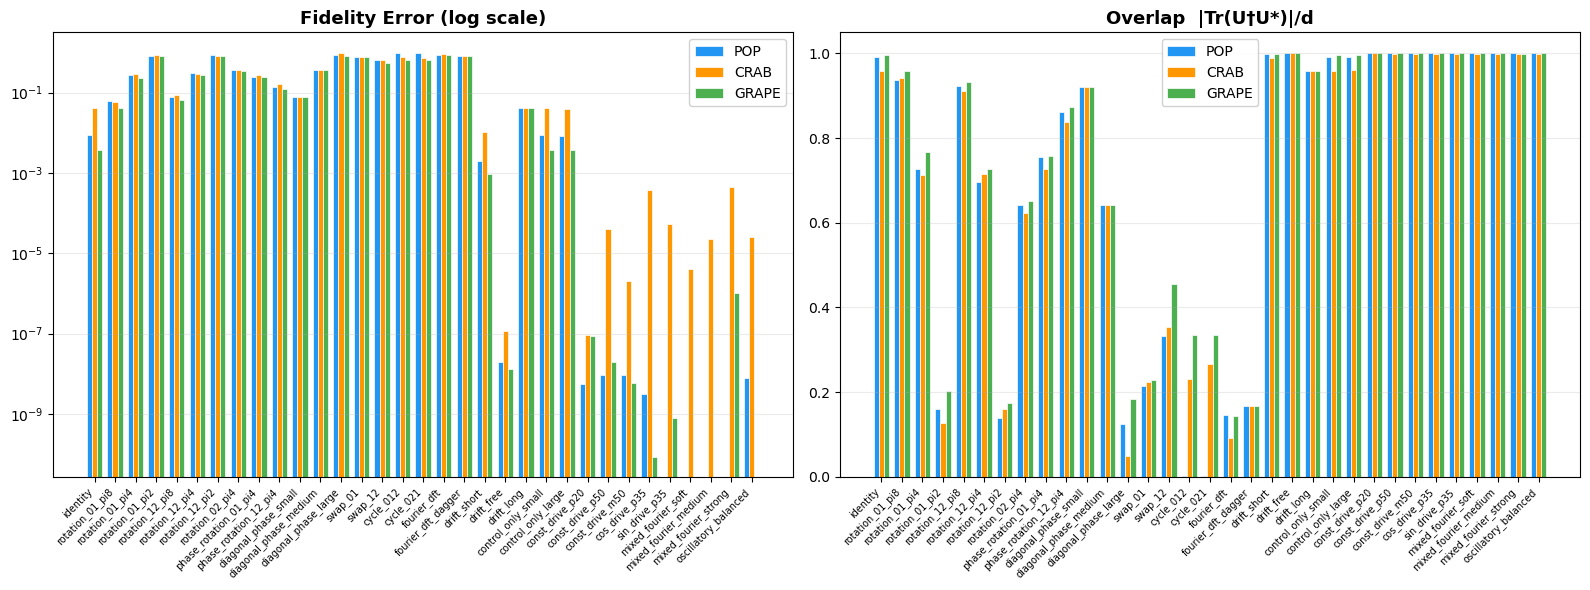

In [42]:
import pandas as pd

# ━━━ Comparison Table ━━━
df = pd.DataFrame({
    'Gate': target_names,
    'POP Fid. Error': pop_fid_error,
    'CRAB Fid. Error': pulseoptim_fid_error,
    'GRAPE Fid. Error': cy_grape_fid_error,
    'POP Overlap': pop_fidelity,
    'CRAB Overlap': pulseoptim_fidelity,
    'GRAPE Overlap': cy_grape_fidelity,
    'CRAB Term.': crab_termination_reason,
    'GRAPE Term.': grape_termination_reason,
})

styled = (
    df.style
    .format({
        'POP Fid. Error':  '{:.2e}', 'CRAB Fid. Error':  '{:.2e}', 'GRAPE Fid. Error': '{:.2e}',
        'POP Overlap':     '{:.6f}', 'CRAB Overlap':     '{:.6f}', 'GRAPE Overlap':    '{:.6f}',
    })
    .background_gradient(subset=['POP Fid. Error', 'CRAB Fid. Error', 'GRAPE Fid. Error'],
                         cmap='RdYlGn_r', axis=None)
    .background_gradient(subset=['POP Overlap', 'CRAB Overlap', 'GRAPE Overlap'],
                         cmap='RdYlGn', axis=None)
    .set_caption("Method Comparison")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding', '8px')]}])
)
display(styled)

# ━━━ Bar Charts ━━━
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(sample)
w = 0.25

for ax, metric, title, labels, cmap in [
    (axes[0],
     [pop_fid_error, pulseoptim_fid_error, cy_grape_fid_error],
     'Fidelity Error (log scale)', ['POP', 'CRAB', 'GRAPE'], ['#2196F3', '#FF9800', '#4CAF50']),
    (axes[1],
     [pop_fidelity, pulseoptim_fidelity, cy_grape_fidelity],
     'Overlap  |Tr(U†U*)|/d', ['POP', 'CRAB', 'GRAPE'], ['#2196F3', '#FF9800', '#4CAF50']),
]:
    for k, (vals, lbl, col) in enumerate(zip(metric, labels, cmap)):
        ax.bar(x + (k - 1) * w, vals, w, label=lbl, color=col, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(target_names, rotation=45, ha='right', fontsize=7)
    ax.legend(framealpha=0.9)
    ax.grid(axis='y', alpha=0.25)

axes[0].set_yscale('log')
plt.tight_layout()
plt.show()

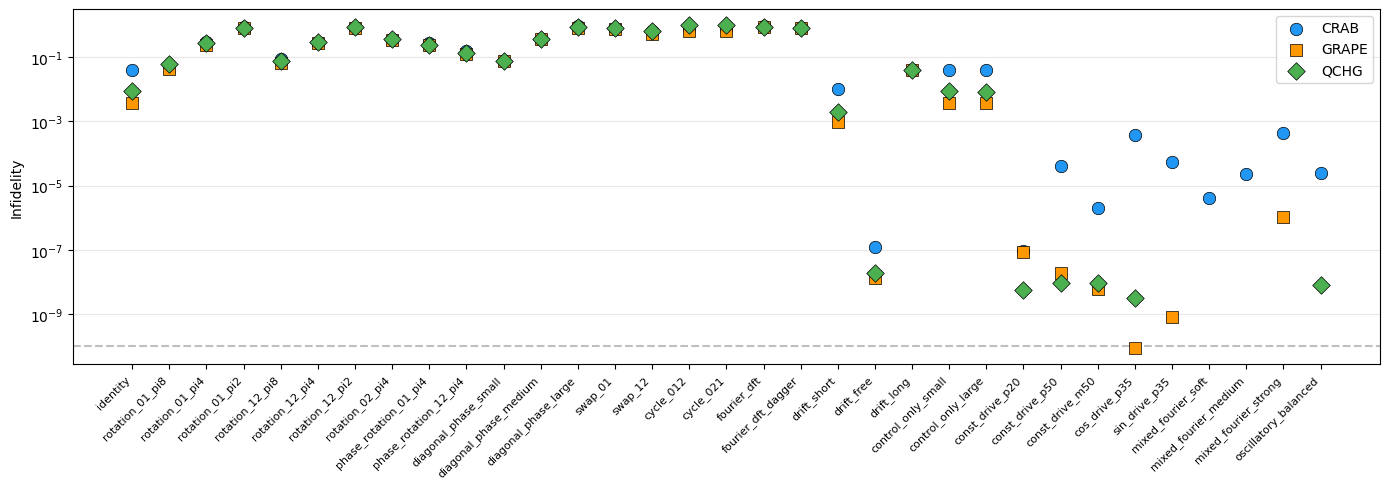

In [43]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(sample)
markers = ['o', 's', 'D']
colors = ['#2196F3', '#FF9800', '#4CAF50']
for vals, label, m, c in zip(
    [pulseoptim_fid_error, cy_grape_fid_error,pop_fid_error],
    ['CRAB', 'GRAPE', 'QCHG'], markers, colors
):
    ax.scatter(x, vals, marker=m, s=80, c=c, label=label, edgecolors='k', linewidths=0.5, zorder=3)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Infidelity')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(1e-10, ls='--', color='grey', alpha=0.5, label='machine precision')
plt.tight_layout()
plt.savefig('infidelity_comparison_scatter.png', dpi=300)
plt.show()

In [44]:
print(f"{'Gate':<30s} {'‖U†U - I‖':>12s}  {'‖UU† - I‖':>12s}  {'|det(U)|-1':>12s}  Unitary?")
print("─" * 90)
for i, name in enumerate(target_names):
    U = U_targets[i, :, :]
    d = U.shape[0]
    err_right = np.linalg.norm(U.conj().T @ U - np.eye(d))
    err_left  = np.linalg.norm(U @ U.conj().T - np.eye(d))
    det_err   = abs(abs(np.linalg.det(U)) - 1)
    ok = err_right < 1e-10 and err_left < 1e-10 and det_err < 1e-10
    print(f"{name:<30s} {err_right:>12.2e}  {err_left:>12.2e}  {det_err:>12.2e}  {'✓' if ok else '✗ NOT UNITARY'}")

Gate                              ‖U†U - I‖     ‖UU† - I‖    |det(U)|-1  Unitary?
──────────────────────────────────────────────────────────────────────────────────────────
identity                           0.00e+00      0.00e+00      0.00e+00  ✓
rotation_01_pi8                    0.00e+00      0.00e+00      0.00e+00  ✓
rotation_01_pi4                    0.00e+00      0.00e+00      0.00e+00  ✓
rotation_01_pi2                    0.00e+00      0.00e+00      0.00e+00  ✓
rotation_12_pi8                    0.00e+00      0.00e+00      0.00e+00  ✓
rotation_12_pi4                    0.00e+00      0.00e+00      0.00e+00  ✓
rotation_12_pi2                    0.00e+00      0.00e+00      0.00e+00  ✓
rotation_02_pi4                    0.00e+00      0.00e+00      0.00e+00  ✓
phase_rotation_01_pi4              0.00e+00      0.00e+00      0.00e+00  ✓
phase_rotation_12_pi4              0.00e+00      0.00e+00      0.00e+00  ✓
diagonal_phase_small               0.00e+00      0.00e+00      0.00e+00  ✓
di